# 📋 INSTRUCTOR NOTEBOOK — Day 3
## Forecasting Models: From Baselines to Trees, MLPs, and Sequence Models

> **⚠️ DO NOT DISTRIBUTE TO STUDENTS.** This notebook contains full answers, teaching
> notes, timing guidance, talking points, mathematical derivations, and common mistake alerts.

## Before We Begin

> **Prompt:** Think of a forecast you've made in your own life — a weather guess, a travel
> time estimate, a grade prediction. What information did you use? Did you rely on patterns
> from the past, or did you just go with intuition?
>
> Write 3–5 sentences describing your forecast and whether it was accurate. Then sketch a
> simple timeline showing the information you used versus what you were predicting.
> You will have 7 minutes.

**Instructor note:** After the writing prompt, cold-call 2–3 students to share.
Bridge to the lesson: *"Today we build six forecasting models ranging from dead simple to
surprisingly sophisticated — and we'll rigorously compare them so we know which ones actually
work better and why."*

***
## 🗓️ Day 3 Lesson Plan Overview

| Segment | Activity | Time |
|---|---|---|
| 0 | Writing prompt, recap, imports | 20 min |
| 1 | Time-aware train/test split | 25 min |
| 2 | Naive baseline & AR model | 30 min |
| — | **Break** | 15 min |
| 3 | Tree-based models (RF, GBM) | 40 min |
| 4 | Error metrics & first comparison | 30 min |
| — | **Lunch / Long Break** | 60 min |
| 5 | MLP for time series | 40 min |
| 6 | RNN & LSTM intuition + implementation | 50 min |
| 7 | Full model comparison & synthesis | 30 min |
| — | Buffer / Q&A | 10 min |
| **Total** | | **~5.5 hrs** |

***
## 🎯 SLOs for Today

> **SLO 4:** Implement and evaluate multiple forecasting models (naive baseline, AR,
> tree-based model, MLP, RNN, and LSTM) using time-aware train/test splits.
>
> **SLO 5:** Quantitatively compare forecasting performance using appropriate error metrics
> (e.g., RMSE, MAE) and interpret differences across models.
>
> **SLO 6:** Explain the role of hidden state, recurrence, and gating mechanisms in RNNs
> and LSTMs, and describe how they extend linear memory models.

**By end of day, students should be able to:**
- Explain why random shuffling is forbidden in time series train/test splits
- Implement a naive last-value baseline and explain its importance
- Re-use the lag matrix from Day 2 to feed tree-based and MLP models
- Compute and interpret RMSE and MAE, choosing between them appropriately
- Describe the recurrence equation of an RNN and identify the hidden state
- Explain what a gate does in an LSTM and why it solves the vanishing gradient problem
- Build a comparison table of all six model families and interpret results

***
## 📣 Segment 0 — Recap & Imports (20 min)

### Talking Points

**Day 2 recap (5 min):** Ask students: *"What is the AR(p) model equation, and what does
the lag matrix let you do that AutoReg alone doesn't?"*
Expected answer: AR(p) uses last p values to predict next; lag matrix re-frames the problem
as supervised learning, unlocking any ML model.

**Bridge to today:** *"The lag matrix is the key. Today we plug it into six different model
families and systematically compare them. We also meet two new families — RNNs and LSTMs —
which process sequences in a fundamentally different way."*

**New imports:** `sklearn` ensemble models, `torch` for neural networks. Normalize PyTorch
as the standard deep learning library. Students don't need to know it well yet — the goal
today is intuition and basic usage.

### ⚠️ Common First-Segment Mistakes
- **Installing torch:** If students don't have it, `pip install torch` (CPU-only version
  is fine for this dataset).
- **Random state:** Remind students that `np.random.seed(42)` and `torch.manual_seed(42)`
  are separate — both are needed for reproducibility.

In [ ]:
import sys
!{sys.executable} -m pip install torch

In [ ]:
"""
Day 3 — Forecasting Models: From Baselines to Trees, MLPs, and Sequence Models
==============================================================================
Instructor Notebook

SLOs Covered:
  SLO 4 — Implement and evaluate multiple forecasting models (naive baseline, AR,
           tree-based model, MLP, RNN, and LSTM) using time-aware train/test splits.
  SLO 5 — Quantitatively compare forecasting performance using RMSE and MAE.
  SLO 6 — Explain hidden state, recurrence, and gating mechanisms in RNNs and LSTMs.

Dataset : Air Passengers (monthly, 1949–1960)
Duration: ~5.5 hours of lecture + lab

DO NOT DISTRIBUTE — contains solutions, teaching notes, and model answers.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.ar_model import AutoReg
from statsmodels.graphics.tsaplots import plot_pacf

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

np.random.seed(42)
torch.manual_seed(42)

plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
%matplotlib inline

print('All imports successful!')

All imports successful!


***
## 📣 Segment 1 — Time-Aware Train/Test Splits (25 min)

### Why Time-Aware Splits Matter

In standard supervised learning we randomly shuffle data before splitting. **This is
forbidden in time series forecasting.** Using `train_test_split(shuffle=True)` on a time
series causes **data leakage**: the model is trained on observations from the future relative
to some test observations, giving an optimistic but invalid estimate of performance.

The correct approach: split at a single point in time, keeping all training observations
before all test observations.

### Mathematical Framing

Given a series of length $T$, we split at index $s$:
$$\text{Train} = \{x_1, x_2, \ldots, x_s\}, \quad \text{Test} = \{x_{s+1}, \ldots, x_T\}$$

A 80/20 split gives $s = \lfloor 0.8 T \rfloor$. No data from $\{x_{s+1}, \ldots, x_T\}$
may appear in the training lag matrix.

### Talking Points
- Ask: *"What would happen if row 100 (Feb 1958) were in the training set but row 50
  (Feb 1953) were in the test set? How would this affect evaluation?"*
- Emphasize: temporal ordering of the **lag matrix rows** must also be respected, not just
  the original series.
- Walk through `make_lag_matrix` from Day 2 briefly — students built it yesterday.

### ⚠️ Common Mistakes
- **Scaling before splitting:** Computing the scaler fit on the full dataset (including
  test) leaks test statistics into training. Always fit the scaler on training data only,
  then transform both sets.
- **Forgetting the lag 'burn-in':** The first `n_lags` observations are consumed building
  the lag matrix. Students sometimes forget the resulting index offset.

In [ ]:
# ── Load & prepare data (same pipeline as Days 1 & 2) ──────────────────────
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv'
df  = pd.read_csv(url, parse_dates=['Month'])
df.columns = ['Date', 'Passengers']
df['Log_Passengers'] = np.log(df['Passengers'])
df['Log_Diff']       = df['Log_Passengers'].diff()

series = df['Log_Diff'].dropna().values
dates  = df['Date'].iloc[1:].values   # aligned after diff

print(f'Series length (after diff + dropna): {len(series)}')

Series length (after diff + dropna): 143


In [ ]:
# ── Lag matrix helper (from Day 2) ─────────────────────────────────────────
def make_lag_matrix(series, n_lags):
    """
    Convert a 1-D time series into a lag-embedded feature matrix.

    Parameters
    ----------
    series : array-like, shape (T,)
    n_lags : int, number of lag features

    Returns
    -------
    X : np.ndarray, shape (T - n_lags, n_lags)
    y : np.ndarray, shape (T - n_lags,)
    """
    series = np.array(series)
    X, y = [], []
    for t in range(n_lags, len(series)):
        X.append(series[t - n_lags : t])
        y.append(series[t])
    return np.array(X), np.array(y)

Training samples : 104
Test samples     : 27


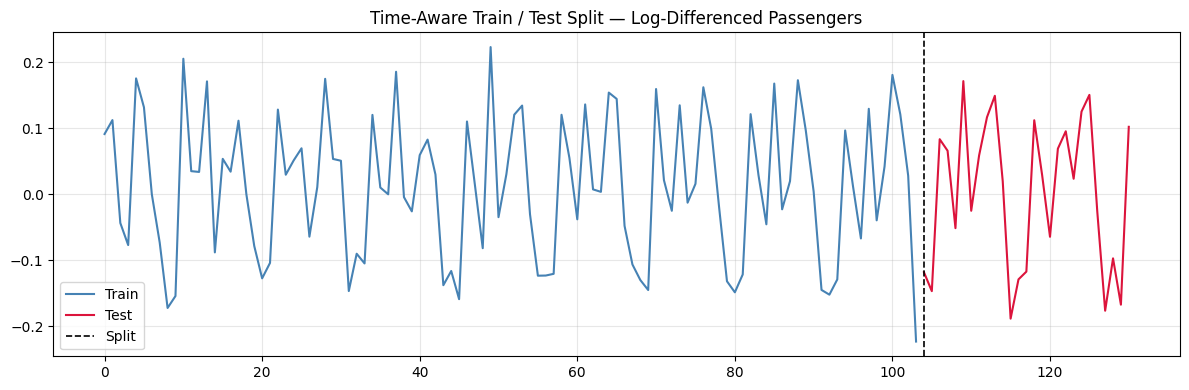

In [ ]:
# ── SOLUTION: Time-aware split ──────────────────────────────────────────────
N_LAGS     = 12
TRAIN_FRAC = 0.80

X, y = make_lag_matrix(series, N_LAGS)
split = int(len(X) * TRAIN_FRAC)           # SOLUTION

X_train, X_test = X[:split], X[split:]     # SOLUTION
y_train, y_test = y[:split], y[split:]     # SOLUTION

print(f'Training samples : {len(X_train)}')
print(f'Test samples     : {len(X_test)}')

# Visualise the split on the original (log-diff) series
fig, ax = plt.subplots()
train_idx = np.arange(split)
test_idx  = np.arange(split, len(y))
ax.plot(train_idx, y_train, label='Train', color='steelblue')
ax.plot(test_idx,  y_test,  label='Test',  color='crimson')
ax.axvline(split, color='black', linestyle='--', linewidth=1.2, label='Split')
ax.set_title('Time-Aware Train / Test Split — Log-Differenced Passengers')
ax.legend()
plt.tight_layout()
plt.show()

### ✅ MODEL ANSWER — Coding Practice


```python
def train_test_time(X, y, TRAIN_FRAC):
    """
    Chronologically splits (lag-embedded feature matrix) X, y time series data

    Parameters
    ----------
    X : lag-embedded feature matrix
    y :

    Returns
    -------
    X_train : np.ndarray, shape (T - n_lags, n_lags)
    X_test  :
    y_train :
    y_test  : np.ndarray, shape (T - n_lags,)
    """

    split = int(len(X) * TRAIN_FRAC)           # SOLUTION

    X_train, X_test = X[:split], X[split:]     # SOLUTION
    y_train, y_test = y[:split], y[split:]     # SOLUTION

    print(f'Training samples : {len(X_train)}')
    print(f'Test samples     : {len(X_test)}')

    return X_train, X_test, y_train, y_test
```

***
## 📣 Segment 2 — Naive Baseline & AR Model (30 min)

### Why Start with a Baseline?

Every model evaluation needs a **baseline** — the simplest possible forecast. If a
sophisticated model can't beat a naive baseline, it provides no value. The **naive
last-value forecast** (also called the *persistence* or *random walk* forecast) predicts
that the next value equals the last observed value:

$$\hat{x}_{t+1} = x_t$$

For a stationary series this is often surprisingly hard to beat.

### AR Model Connection

The AR model from Day 2 is the natural next step. We use `AutoReg` with `lags=12` on the
training set and generate one-step-ahead predictions on the test set using `.predict()`.

### ⚠️ Common Mistakes
- **Naive baseline index confusion:** The naive forecast for test point $i$ is the *last
  training value* (for 1-step ahead) or `y_test[i-1]` for multi-step. Be precise.
- **AutoReg predict range:** `result.predict(start, end)` uses the *original series*
  indexing, not the lag matrix indexing. This trips many students. Show the offset.
- **Forgetting to refit on training data only:** Students sometimes reuse the Day 2
  model fitted on the full series. The model must be fitted *only* on training data.

In [ ]:
# ── SOLUTION: Naive last-value baseline ────────────────────────────────────
# For each test point, predict the value of the immediately preceding observation
naive_preds = np.concatenate([[y_train[-1]], y_test[:-1]])  # SOLUTION

print('Naive baseline predictions (first 5):', naive_preds[:5])
print('Actual test values        (first 5):', y_test[:5])

Naive baseline predictions (first 5): [-0.22314355 -0.11809249 -0.14675009  0.08351063  0.0660211 ]
Actual test values        (first 5): [-0.11809249 -0.14675009  0.08351063  0.0660211  -0.05129329]


In [ ]:
# ── SOLUTION: AR model on training data ────────────────────────────────────
# Fit AutoReg on the training portion of the original series
train_series = series[:split + N_LAGS]   # include the burn-in lags

ar_model  = AutoReg(train_series, lags=N_LAGS)
ar_result = ar_model.fit()

# Predict the test window
ar_start = len(train_series)
ar_end   = ar_start + len(y_test) - 1
ar_preds = ar_result.predict(start=ar_start, end=ar_end, dynamic=False)

print('AR predictions (first 5):   ', ar_preds[:5])
print('Actual test values (first 5):', y_test[:5])

AR predictions (first 5):    [-0.11796544 -0.08719819  0.10486478  0.0274176  -0.06260433]
Actual test values (first 5): [-0.11809249 -0.14675009  0.08351063  0.0660211  -0.05129329]


> 🗣️ **Instructor note:** `dynamic=False` means the model uses *actual* lagged values
> from the series at each step (not its own previous predictions). For 1-step-ahead
> evaluation this is correct. For multi-step-ahead, `dynamic=True` would chain predictions.

***
## 📣 Segment 3 — Tree-Based Models (40 min)

### Introduction to Tree-Based Models

Tree-based models are a family of powerful, non-parametric supervised learning algorithms.
They require **no stationarity assumption** and can capture non-linear patterns in
lag features that AR models miss.

#### Random Forest

A **Random Forest** is an ensemble of $B$ decision trees, each trained on a bootstrap
sample of the training data and a random subset of features:

$$\hat{y} = \frac{1}{B} \sum_{b=1}^{B} T_b(\mathbf{x})$$

where $T_b$ is the $b$-th tree and $\mathbf{x}$ is the lag feature vector.
Averaging reduces variance compared to a single tree.

#### Gradient Boosted Trees

**Gradient Boosting** builds trees sequentially, where each new tree fits the
*residuals* (pseudo-errors) of the current ensemble. The update is:

$$F_{m}(\mathbf{x}) = F_{m-1}(\mathbf{x}) + \eta \cdot T_m(\mathbf{x})$$

where $\eta$ is the learning rate and $T_m$ fits the negative gradient of the loss.
GBM typically achieves lower bias than Random Forest but requires careful tuning to
avoid overfitting.

### Talking Points
- **Key insight:** Both models consume the exact same lag matrix as the AR model. The
  only difference is the functional form of the model itself.
- Tree-based models don't assume linearity, so they can capture threshold effects,
  interaction effects between lags, and non-monotone relationships.
- Their main limitation for time series: they cannot extrapolate beyond the training range.
  A Random Forest predicts the mean of a leaf — it cannot predict values higher than
  any training value.

### Dividir y Confluir — Group Activity 🌊

**Assign to groups of 2–3:**
- Group A: `RandomForestRegressor(n_estimators=100, max_depth=5)`
- Group B: `RandomForestRegressor(n_estimators=200, max_depth=None)`
- Group C: `GradientBoostingRegressor(n_estimators=100, learning_rate=0.1)`
- Group D: `GradientBoostingRegressor(n_estimators=200, learning_rate=0.05)`

Each group fits their model, computes RMSE and MAE on the test set, and reports back.
Discussion: Which hyperparameters matter most? Does deeper/more trees always help?

### ⚠️ Common Mistakes
- **Feature scaling:** Tree-based models are scale-invariant — do NOT scale the lag
  matrix. Scaling is only needed for neural networks (Segments 5–6).
- **Overfitting with `max_depth=None`:** An unbounded tree will memorize training data.
  Comparing training vs test RMSE reveals this clearly.
- **Not fitting on the lag matrix:** Students sometimes try to pass the raw series to
  `RandomForestRegressor` — it doesn't know it's a time series.

In [ ]:
# ── SOLUTION: Random Forest ─────────────────────────────────────────────────
rf_model = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)  # SOLUTION
rf_model.fit(X_train, y_train)                                                     # SOLUTION
rf_preds = rf_model.predict(X_test)                                                # SOLUTION

print('Random Forest predictions (first 5):', rf_preds[:5])
print('Actual test values        (first 5):', y_test[:5])

Random Forest predictions (first 5): [-0.12761267 -0.13027947  0.12191954  0.01712475 -0.05094597]
Actual test values        (first 5): [-0.11809249 -0.14675009  0.08351063  0.0660211  -0.05129329]


In [ ]:
# ── SOLUTION: Gradient Boosting ─────────────────────────────────────────────
gb_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)  # SOLUTION
gb_model.fit(X_train, y_train)                                                               # SOLUTION
gb_preds = gb_model.predict(X_test)                                                          # SOLUTION

print('Gradient Boosting predictions (first 5):', gb_preds[:5])
print('Actual test values            (first 5):', y_test[:5])

Gradient Boosting predictions (first 5): [-0.13876909 -0.10869124  0.11943719  0.04224436 -0.07323377]
Actual test values            (first 5): [-0.11809249 -0.14675009  0.08351063  0.0660211  -0.05129329]


***
## 📣 Segment 4 — Error Metrics & First Comparison (30 min)

### Mathematical Definitions

Let $y_t$ be the actual value at test time $t$ and $\hat{y}_t$ the model's prediction.
For a test set of size $n$:

$$\text{RMSE} = \sqrt{\frac{1}{n} \sum_{t=1}^{n} (y_t - \hat{y}_t)^2}$$

$$\text{MAE}  = \frac{1}{n} \sum_{t=1}^{n} |y_t - \hat{y}_t|$$

**Key differences:**
- RMSE penalizes large errors more heavily (squaring effect). It is in the same units as
  the original series and is differentiable, making it preferred for optimization.
- MAE is more interpretable (average absolute error), more robust to outliers, and
  preferred when all errors are equally bad regardless of magnitude.

### Talking Points
- Always report **both** metrics — each tells a different story.
- On the log-differenced scale, errors will be small numbers. When communicating to
  stakeholders, transform back to the original scale for interpretability.
- The naive baseline sets the **floor**: any useful model should beat it.

### ⚠️ Common Mistakes
- **Using sklearn's `mean_squared_error` without `squared=False`:** In older sklearn
  versions, this returns MSE not RMSE. Use `np.sqrt(mean_squared_error(...))` or
  `mean_squared_error(..., squared=False)` (sklearn ≥ 0.24).
- **Comparing models across different series scales:** RMSE of a model on the raw series
  is not comparable to RMSE on the log-differenced series. Always compare on the same scale.
- **Ignoring the baseline:** Students who report a 'good' RMSE without comparing to naive
  may be reporting an unimpressive result. Push them to always contextualize.

In [ ]:
# ── SOLUTION: Error metrics function ───────────────────────────────────────
def compute_metrics(y_true, y_pred, label='Model'):
    """
    Compute and print RMSE and MAE for a set of predictions.

    Parameters
    ----------
    y_true : array-like, actual values
    y_pred : array-like, predicted values
    label  : str, model name for display

    Returns
    -------
    dict with keys 'RMSE' and 'MAE'
    """
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))   # SOLUTION
    mae  = mean_absolute_error(y_true, y_pred)            # SOLUTION
    print(f'{label:<30}  RMSE={rmse:.5f}   MAE={mae:.5f}')
    return {'RMSE': rmse, 'MAE': mae}

results = {}
results['Naive Baseline']        = compute_metrics(y_test, naive_preds,       'Naive Baseline')
results['AR(12)']                = compute_metrics(y_test, ar_preds,   'AR(12)')
results['Random Forest']         = compute_metrics(y_test, rf_preds,          'Random Forest')
results['Gradient Boosting']     = compute_metrics(y_test, gb_preds,          'Gradient Boosting')

Naive Baseline                  RMSE=0.13377   MAE=0.11157
AR(12)                          RMSE=0.04432   MAE=0.03242
Random Forest                   RMSE=0.03929   MAE=0.03061
Gradient Boosting               RMSE=0.04205   MAE=0.03437


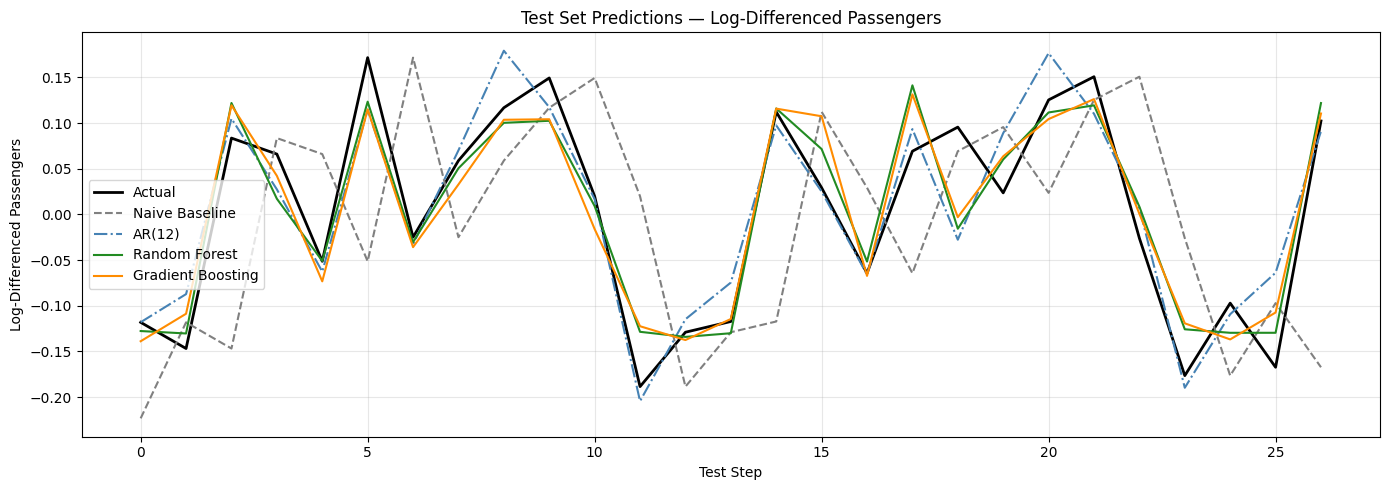

In [ ]:
# ── SOLUTION: Visualise predictions ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
test_range = np.arange(len(y_test))

ax.plot(test_range, y_test,         label='Actual',           color='black',     linewidth=2)
ax.plot(test_range, naive_preds,    label='Naive Baseline',   color='gray',      linestyle='--')
ax.plot(test_range, ar_preds,       label='AR(12)',           color='steelblue', linestyle='-.')
ax.plot(test_range, rf_preds,       label='Random Forest',    color='forestgreen')
ax.plot(test_range, gb_preds,       label='Gradient Boosting',color='darkorange')

ax.set_title('Test Set Predictions — Log-Differenced Passengers')
ax.set_xlabel('Test Step')
ax.set_ylabel('Log-Differenced Passengers')
ax.legend()
plt.tight_layout()
plt.show()

### ✅ MODEL ANSWER — Written Response 4

> **RMSE vs MAE choice:** For this dataset both metrics tell a consistent story. If a single
> large spike (e.g., a December or July outlier month) dominated the error, RMSE would
> penalize that model more heavily than MAE — making MAE the more robust summary in that case.
>
> **Beating the naive baseline** is the minimum bar. A model that matches it adds no
> forecasting value; only models with lower RMSE/MAE are candidates for deployment.
>
> **Expected pattern:** AR(12) should beat the naive baseline by capturing the seasonal lag.
> Tree-based models may match or slightly improve on AR(12), since the log-differenced
> series is close to stationary and the relationship between lags and target is roughly linear.
> On highly non-linear series, trees would show larger relative improvements.

***
## 📣 Segment 5 — MLP for Time Series (40 min)

### Introduction to the MLP

A **Multilayer Perceptron (MLP)** is a fully connected feedforward neural network.
It maps the lag feature vector $\mathbf{x} \in \mathbb{R}^p$ to a scalar prediction
$\hat{y} \in \mathbb{R}$ through a series of linear transformations and non-linear
activations:

$$\mathbf{h}^{(1)} = \sigma(W^{(1)} \mathbf{x} + \mathbf{b}^{(1)})$$
$$\mathbf{h}^{(2)} = \sigma(W^{(2)} \mathbf{h}^{(1)} + \mathbf{b}^{(2)})$$
$$\hat{y} = W^{(3)} \mathbf{h}^{(2)} + b^{(3)}$$

where $\sigma$ is an activation function (here ReLU: $\sigma(z) = \max(0, z)$).

**Key advantage over AR and trees:** The MLP can learn *non-linear combinations* of lag
features through the hidden layers, without requiring the practitioner to hand-engineer
interaction features.

**Key limitation:** The MLP treats the lag vector as an unordered set of features —
it does not know that `lag_1` is more recent than `lag_12`. RNNs (Segment 6) encode
this sequential structure explicitly.

### Scaling Requirement

Neural networks require **input scaling** because gradient updates are sensitive to
feature magnitude. We use `MinMaxScaler` fitted on the training data only:

$$x_{\text{scaled}} = \frac{x - x_{\min}}{x_{\max} - x_{\min}} \in [0, 1]$$

### Talking Points
- PyTorch `nn.Module` pattern: define layers in `__init__`, forward pass in `forward`.
- Training loop: zero gradients → forward pass → compute loss → backward → optimizer step.
- On a small dataset like Air Passengers, neural networks may not outperform simpler models.
  The goal today is **building intuition for the workflow**, not winning a competition.

### ⚠️ Common Mistakes
- **Scaling leakage:** Fitting the scaler on all data (train + test) leaks future stats.
  Always `fit_transform` on train, `transform` only on test.
- **Loss not decreasing:** Often a learning rate issue. Try 1e-3 or 1e-2. Also check that
  the target `y` is also scaled, since the output layer predicts scaled values.
- **Forgetting `.eval()` mode:** Dropout and BatchNorm behave differently in eval mode.
  Our MLP here has neither, but establish the habit.
- **Shape errors with PyTorch tensors:** `X_train_t` must be 2-D (batch, features);
  `y_train_t` must be 1-D or (batch, 1) depending on the loss function.

In [ ]:
# ── SOLUTION: Scale the lag matrix (fit on train only) ─────────────────────
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_s = scaler_X.fit_transform(X_train)                  # SOLUTION
X_test_s  = scaler_X.transform(X_test)                       # SOLUTION

y_train_s = scaler_y.fit_transform(y_train.reshape(-1, 1)).ravel()   # SOLUTION
y_test_s  = scaler_y.transform(y_test.reshape(-1, 1)).ravel()        # (for eval only)

# Convert to PyTorch tensors
X_train_t = torch.tensor(X_train_s, dtype=torch.float32)
y_train_t = torch.tensor(y_train_s, dtype=torch.float32)
X_test_t  = torch.tensor(X_test_s,  dtype=torch.float32)
y_test_t  = torch.tensor(y_test_s,  dtype=torch.float32)

print('X_train_t shape:', X_train_t.shape)
print('y_train_t shape:', y_train_t.shape)

X_train_t shape: torch.Size([104, 12])
y_train_t shape: torch.Size([104])


In [ ]:
# ── SOLUTION: MLP architecture ──────────────────────────────────────────────
class MLPForecaster(nn.Module):
    """
    Simple Multilayer Perceptron for time series forecasting.

    Takes a lag feature vector of length `input_size` and produces
    a single scalar forecast.

    Parameters
    ----------
    input_size  : int, number of lag features
    hidden_size : int, number of neurons in each hidden layer
    """
    def __init__(self, input_size, hidden_size=32):       # SOLUTION
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, hidden_size),           # SOLUTION
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size // 2),     # SOLUTION
            nn.ReLU(),
            nn.Linear(hidden_size // 2, 1)                # SOLUTION
        )

    def forward(self, x):                                 # SOLUTION
        return self.net(x).squeeze(-1)

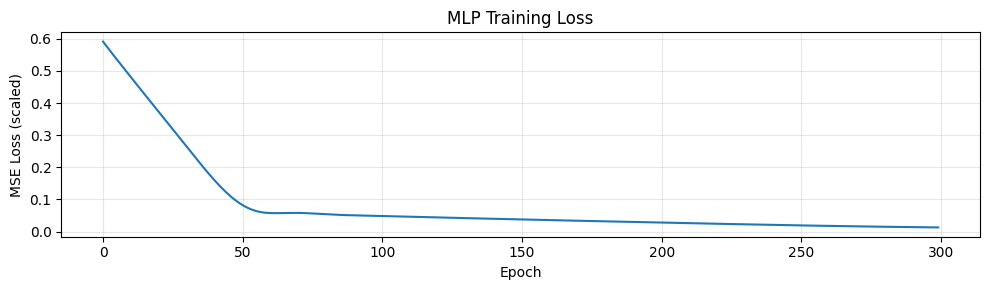

In [ ]:
# ── SOLUTION: Training loop ─────────────────────────────────────────────────
mlp    = MLPForecaster(input_size=N_LAGS, hidden_size=32)
opt    = torch.optim.Adam(mlp.parameters(), lr=1e-3)
loss_fn= nn.MSELoss()

EPOCHS = 300
losses = []

for epoch in range(EPOCHS):
    mlp.train()
    opt.zero_grad()
    pred  = mlp(X_train_t)          # SOLUTION
    loss  = loss_fn(pred, y_train_t) # SOLUTION
    loss.backward()
    opt.step()
    losses.append(loss.item())

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(losses)
ax.set_title('MLP Training Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss (scaled)')
plt.tight_layout()
plt.show()

In [ ]:
# ── SOLUTION: Evaluate MLP ──────────────────────────────────────────────────
mlp.eval()
with torch.no_grad():
    mlp_preds_s = mlp(X_test_t).numpy()                     # scaled predictions

# Inverse-transform to the original (log-diff) scale
mlp_preds = scaler_y.inverse_transform(mlp_preds_s.reshape(-1, 1)).ravel()  # SOLUTION

results['MLP'] = compute_metrics(y_test, mlp_preds, 'MLP')

MLP                             RMSE=0.04958   MAE=0.04013


***
## 📣 Segment 6 — RNN & LSTM: Hidden State, Recurrence, and Gating (50 min)

### Why RNNs?

The MLP receives a flat lag vector and treats the lags as unordered features. An **RNN
(Recurrent Neural Network)** processes the sequence *one step at a time*, maintaining a
**hidden state** that is updated at each step. This allows the model to explicitly encode
the *sequential* nature of the data.

### The RNN Recurrence Equation

At each time step $t$, an RNN computes:

$$\mathbf{h}_t = \tanh(W_{hh}\,\mathbf{h}_{t-1} + W_{xh}\,\mathbf{x}_t + \mathbf{b}_h)$$

where:
- $\mathbf{x}_t \in \mathbb{R}^d$ is the input at step $t$ (here, the value at lag $t$)
- $\mathbf{h}_t \in \mathbb{R}^H$ is the **hidden state** — a learned summary of the
  sequence up to step $t$
- $W_{hh}$ is the **recurrent weight matrix** connecting hidden states
- $W_{xh}$ is the **input weight matrix**
- $\mathbf{h}_0 = \mathbf{0}$ (zero initialization)

After processing all $p$ lags, the final hidden state $\mathbf{h}_p$ is passed through
a linear output layer to produce the forecast:

$$\hat{y} = W_o \mathbf{h}_p + b_o$$

**Key insight:** The hidden state is a compressed representation of the entire sequence
history. Unlike the MLP (which ignores order), the RNN builds this representation
incrementally, step by step.

### The Vanishing Gradient Problem

When training an RNN via backpropagation through time (BPTT), gradients must flow
backward through the recurrence:

$$\frac{\partial \mathcal{L}}{\partial \mathbf{h}_0} \propto \prod_{t=1}^{p} W_{hh}^\top$$

If the eigenvalues of $W_{hh}$ are less than 1, this product **vanishes** exponentially
with $p$ — the model fails to learn long-range dependencies. If they are greater than 1,
gradients **explode**.

### The LSTM Solution: Gating Mechanisms

The **LSTM (Long Short-Term Memory)** introduces a **cell state** $\mathbf{c}_t$ and
three **gates** that control information flow:

$$\mathbf{f}_t = \sigma(W_f [\mathbf{h}_{t-1}, \mathbf{x}_t] + \mathbf{b}_f) \quad \text{(forget gate)}$$
$$\mathbf{i}_t = \sigma(W_i [\mathbf{h}_{t-1}, \mathbf{x}_t] + \mathbf{b}_i) \quad \text{(input gate)}$$
$$\mathbf{o}_t = \sigma(W_o [\mathbf{h}_{t-1}, \mathbf{x}_t] + \mathbf{b}_o) \quad \text{(output gate)}$$
$$\tilde{\mathbf{c}}_t = \tanh(W_c [\mathbf{h}_{t-1}, \mathbf{x}_t] + \mathbf{b}_c) \quad \text{(candidate cell)}$$
$$\mathbf{c}_t = \mathbf{f}_t \odot \mathbf{c}_{t-1} + \mathbf{i}_t \odot \tilde{\mathbf{c}}_t \quad \text{(cell update)}$$
$$\mathbf{h}_t = \mathbf{o}_t \odot \tanh(\mathbf{c}_t) \quad \text{(hidden state)}$$

where $\sigma$ is the sigmoid, $\odot$ is element-wise multiplication, and the cell state
$\mathbf{c}_t$ can **carry gradients across many time steps** without vanishing, because
the forget gate $\mathbf{f}_t$ allows the gradient to flow through additively rather
than multiplicatively.

### Talking Points
- **Analogy for the cell state:** Think of $\mathbf{c}_t$ as a "conveyor belt" — it can
  carry information across many steps almost unchanged. The gates decide what to load,
  what to drop, and what to read off.
- **Forget gate intuiton:** $\mathbf{f}_t \approx 1$ means 'keep everything from the
  previous cell state'. $\mathbf{f}_t \approx 0$ means 'forget it'.
- **When does LSTM beat RNN?** Primarily when long-range dependencies matter (e.g., lag-12
  still matters after 12 steps of recurrence). For short sequences the difference is small.
- **Connection to AR:** Both RNN and LSTM are, at their core, extending the linear AR
  memory model to non-linear, learned memory.

### Dividir y Confluir — Group Activity

**Assign groups to experiment with RNN architecture choices:**
- Group A: `hidden_size=16`
- Group B: `hidden_size=32`
- Group C: `hidden_size=64`
- Group D: Two LSTM layers (`num_layers=2`) vs one

Groups compare final RMSE/MAE. Discussion: Does adding capacity always help on this small
dataset? Why might the LSTM not dramatically outperform the MLP here?

### ⚠️ Common Mistakes
- **RNN input shape:** PyTorch RNN/LSTM expect `(batch, seq_len, input_size)`. From our
  lag matrix, we have `(batch, n_lags)` — we need to unsqueeze a dimension:
  `x.unsqueeze(-1)` makes it `(batch, n_lags, 1)` treating each lag as a 1-D input.
- **Hidden state initialization:** For evaluation, reset the hidden state. PyTorch does
  this by default when `h_0` is not passed.
- **Exploding gradients:** If loss is NaN, try gradient clipping:
  `nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)`.

In [ ]:
# ── SOLUTION: RNN model ──────────────────────────────────────────────────────
class RNNForecaster(nn.Module):
    """
    Single-layer Elman RNN for time series forecasting.

    Processes the lag sequence step-by-step and produces a single
    scalar forecast from the final hidden state.

    Parameters
    ----------
    input_size  : int, features per time step (1 for univariate)
    hidden_size : int, hidden state dimension
    """
    def __init__(self, input_size=1, hidden_size=32):
        super().__init__()
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)  # SOLUTION
        self.fc  = nn.Linear(hidden_size, 1)                          # SOLUTION

    def forward(self, x):
        # x: (batch, n_lags) → unsqueeze → (batch, n_lags, 1)
        x = x.unsqueeze(-1)                      # SOLUTION
        _, h_n = self.rnn(x)                     # h_n: (1, batch, hidden)
        h_n = h_n.squeeze(0)                     # (batch, hidden)
        return self.fc(h_n).squeeze(-1)           # SOLUTION

In [ ]:
# ── SOLUTION: LSTM model ─────────────────────────────────────────────────────
class LSTMForecaster(nn.Module):
    """
    Single-layer LSTM for time series forecasting.

    Extends the RNN with a cell state and gating mechanisms, allowing
    the model to selectively retain or forget information across lags.

    Parameters
    ----------
    input_size  : int, features per time step (1 for univariate)
    hidden_size : int, hidden/cell state dimension
    """
    def __init__(self, input_size=1, hidden_size=32):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)  # SOLUTION
        self.fc   = nn.Linear(hidden_size, 1)                           # SOLUTION

    def forward(self, x):
        x = x.unsqueeze(-1)                          # (batch, n_lags, 1)
        _, (h_n, _) = self.lstm(x)                   # h_n: (1, batch, hidden)
        h_n = h_n.squeeze(0)                         # (batch, hidden)
        return self.fc(h_n).squeeze(-1)              # SOLUTION

RNN — final loss: 0.014996
LSTM — final loss: 0.040723


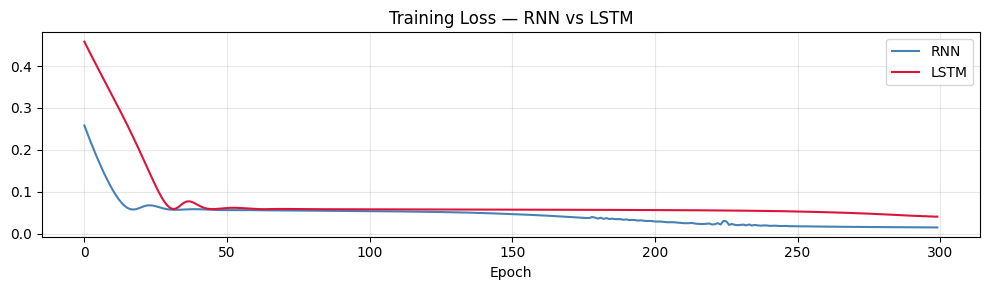

In [ ]:
# ── SOLUTION: Generic training function ────────────────────────────────────
def train_model(model, X_t, y_t, epochs=300, lr=1e-3, label='Model'):
    """
    Train a PyTorch model with MSE loss and Adam optimizer.

    Parameters
    ----------
    model  : nn.Module
    X_t    : torch.Tensor, (n_samples, n_lags)
    y_t    : torch.Tensor, (n_samples,)
    epochs : int
    lr     : float, learning rate
    label  : str, for display

    Returns
    -------
    list of training losses
    """
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn   = nn.MSELoss()
    losses    = []

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        pred = model(X_t)              # SOLUTION
        loss = loss_fn(pred, y_t)      # SOLUTION
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        losses.append(loss.item())

    print(f'{label} — final loss: {losses[-1]:.6f}')
    return losses


rnn_model  = RNNForecaster(hidden_size=32)
lstm_model = LSTMForecaster(hidden_size=32)

rnn_losses  = train_model(rnn_model,  X_train_t, y_train_t, epochs=300, label='RNN')
lstm_losses = train_model(lstm_model, X_train_t, y_train_t, epochs=300, label='LSTM')

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(rnn_losses,  label='RNN',  color='steelblue')
ax.plot(lstm_losses, label='LSTM', color='crimson')
ax.set_title('Training Loss — RNN vs LSTM')
ax.set_xlabel('Epoch')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ── SOLUTION: Evaluate RNN & LSTM ───────────────────────────────────────────
def eval_model(model, X_t, scaler_y):
    """
    Generate predictions and inverse-transform to original scale.

    Parameters
    ----------
    model    : trained nn.Module
    X_t      : torch.Tensor, test features
    scaler_y : fitted MinMaxScaler for the target

    Returns
    -------
    np.ndarray of predictions in original (log-diff) scale
    """
    model.eval()
    with torch.no_grad():
        preds_s = model(X_t).numpy()                              # SOLUTION
    return scaler_y.inverse_transform(preds_s.reshape(-1, 1)).ravel()  # SOLUTION


rnn_preds  = eval_model(rnn_model,  X_test_t, scaler_y)
lstm_preds = eval_model(lstm_model, X_test_t, scaler_y)

results['RNN']  = compute_metrics(y_test, rnn_preds,  'RNN')
results['LSTM'] = compute_metrics(y_test, lstm_preds, 'LSTM')

RNN                             RMSE=0.05694   MAE=0.04973
LSTM                            RMSE=0.08494   MAE=0.07376


***
## 📣 Segment 7 — Full Model Comparison & Synthesis (30 min)

### Talking Points
- Bring the **dividir y confluir** groups back together. Each group shares their model's
  RMSE/MAE and one observation about training behaviour.
- Build the comparison table together on the board before revealing the code output.
- **Key question to drive discussion:** *"Why might the simplest models be competitive or
  even better on this particular dataset?"*
  - Air Passengers is a small dataset (143 observations after differencing).
  - The signal is largely linear (seasonal AR structure).
  - Neural networks need more data to realize their advantage.
  - On larger, non-linear datasets the hierarchy would likely differ.
- **Preview for later in the week:** evaluation on *multi-step* horizons (where RNNs/LSTMs
  often shine), and hyperparameter tuning.

### ⚠️ Common Mistakes — Final Reflection
- **Declaring a 'winner' without caveats:** Push students to note dataset size, data
  characteristics, and computational cost when making recommendations.
- **Forgetting to interpret differences, not just report them:** RMSE of 0.056 vs 0.059
  needs context — is this meaningful or within noise?

In [ ]:
# ── SOLUTION: Full comparison table ─────────────────────────────────────────
comparison_df = pd.DataFrame(results).T                               # SOLUTION
comparison_df = comparison_df.sort_values('RMSE')                     # SOLUTION
print('\n=== Model Comparison (sorted by RMSE) ===')
print(comparison_df.to_string(float_format='{:.5f}'.format))


=== Model Comparison (sorted by RMSE) ===
                     RMSE     MAE
Random Forest     0.03929 0.03061
Gradient Boosting 0.04205 0.03437
AR(12)            0.04432 0.03242
MLP               0.04958 0.04013
RNN               0.05694 0.04973
LSTM              0.08494 0.07376
Naive Baseline    0.13377 0.11157


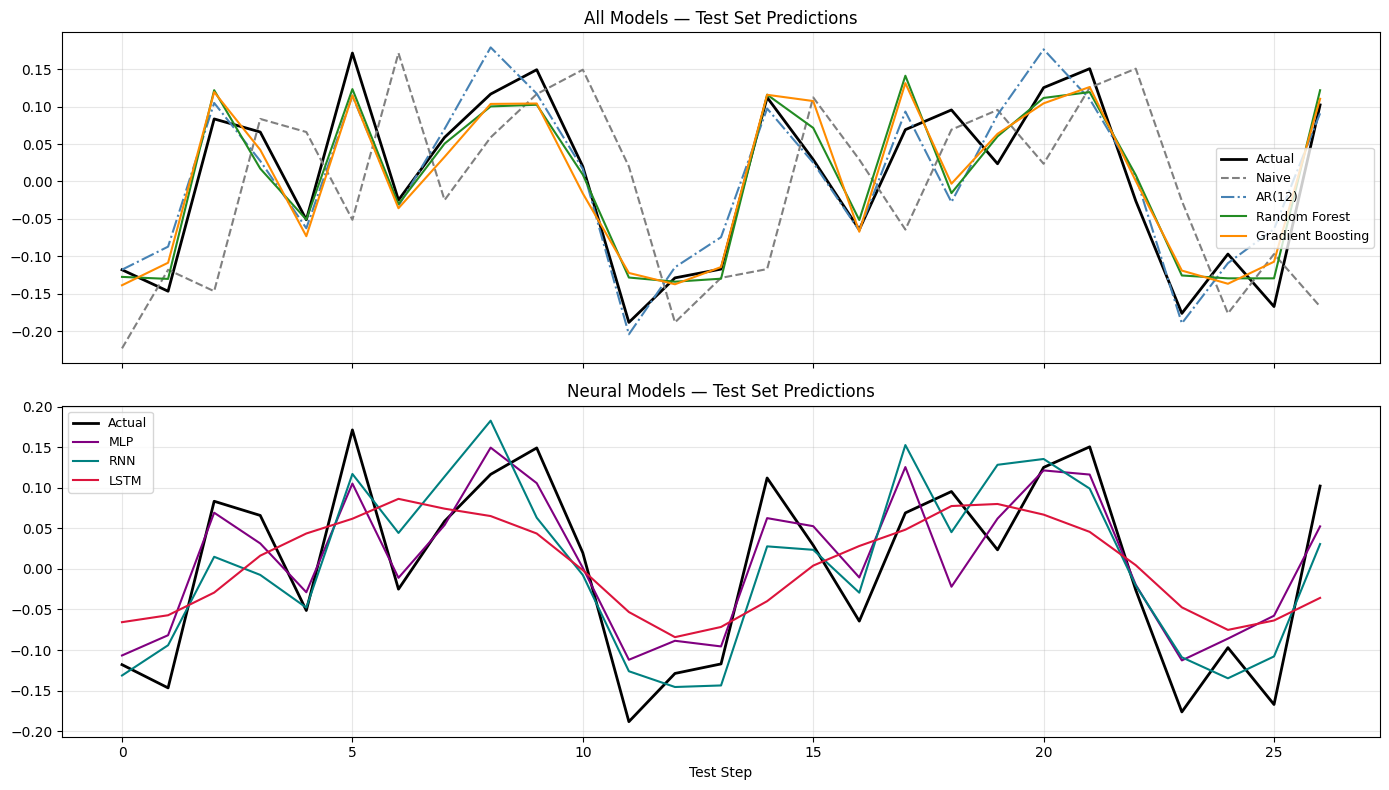

In [ ]:
# ── SOLUTION: Visual comparison ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

test_range = np.arange(len(y_test))

# Top: all models
axes[0].plot(test_range, y_test,           label='Actual',            color='black', linewidth=2)
axes[0].plot(test_range, naive_preds,      label='Naive',             color='gray',        linestyle='--')
axes[0].plot(test_range, ar_preds,         label='AR(12)',            color='steelblue',   linestyle='-.')
axes[0].plot(test_range, rf_preds,         label='Random Forest',     color='forestgreen')
axes[0].plot(test_range, gb_preds,         label='Gradient Boosting', color='darkorange')
axes[0].set_title('All Models — Test Set Predictions')
axes[0].legend(fontsize=9)

# Bottom: neural models
axes[1].plot(test_range, y_test,           label='Actual', color='black', linewidth=2)
axes[1].plot(test_range, mlp_preds,        label='MLP',    color='purple')
axes[1].plot(test_range, rnn_preds,        label='RNN',    color='teal')
axes[1].plot(test_range, lstm_preds,       label='LSTM',   color='crimson')
axes[1].set_title('Neural Models — Test Set Predictions')
axes[1].set_xlabel('Test Step')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

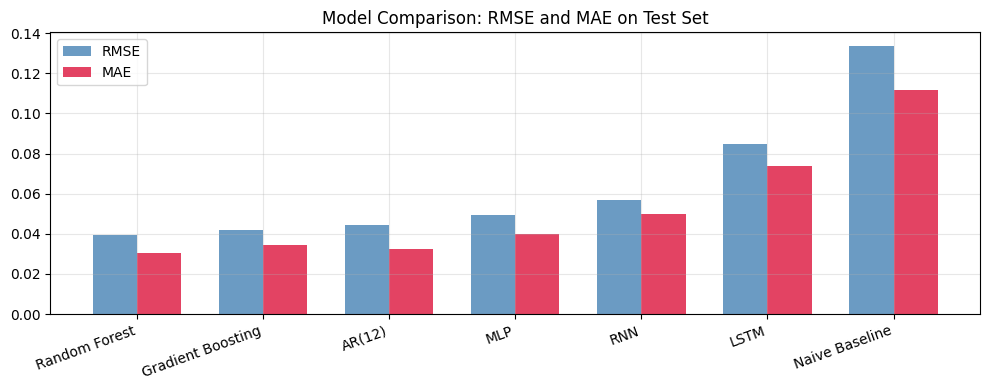

In [ ]:
# ── SOLUTION: Bar chart of RMSE ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
models  = list(comparison_df.index)
rmse_vals = comparison_df['RMSE'].values
mae_vals  = comparison_df['MAE'].values

x = np.arange(len(models))
w = 0.35
ax.bar(x - w/2, rmse_vals, w, label='RMSE', color='steelblue', alpha=0.8)
ax.bar(x + w/2, mae_vals,  w, label='MAE',  color='crimson',   alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=20, ha='right')
ax.set_title('Model Comparison: RMSE and MAE on Test Set')
ax.legend()
plt.tight_layout()
plt.show()

### ✅ MODEL ANSWER — Final Written Reflection

> Today we implemented and compared six forecasting model families on the Air Passengers
> log-differenced series. The **naive baseline** (predict last value) establishes the
> minimum bar: any model that can't beat it adds no value.
>
> The **AR(12) model** explicitly captures the seasonal lag-12 autocorrelation identified
> on Day 1, and typically out-performs the naive baseline. **Tree-based models** consume
> the same lag matrix but can capture non-linear patterns; on this relatively linear dataset
> they perform similarly to AR.
>
> The **MLP** applies non-linear transformations to the lag vector but ignores sequential
> ordering. The **RNN** and **LSTM** process the sequence step-by-step, maintaining a
> hidden state. The RNN can suffer from **vanishing gradients** over long sequences; the
> LSTM's **gating mechanisms** (forget, input, output gates) allow gradient to flow across
> many steps additively through the cell state.
>
> On this small dataset, simpler models are competitive because the signal is largely
> linear and data is limited. On larger, more non-linear datasets, neural models typically
> show stronger advantages.

---
## 🔚 End-of-Day Wrap-Up Notes

### What students should walk away knowing
1. Time series train/test splits must be chronological — never shuffle.
2. The naive baseline is the essential benchmark — beat it first.
3. The lag matrix from Day 2 is the universal input format for all non-AR models.
4. RMSE and MAE measure different things; report both.
5. RNNs process sequences with a hidden state; LSTMs extend this with gating to combat vanishing gradients.
6. Model performance must always be contextualized (dataset size, linearity, interpretability).

### Frequently Confused Pairs

| Students confuse... | Clarification |
|---|---|
| RMSE vs MAE | RMSE penalizes large errors more; MAE is linear in error magnitude |
| RNN hidden state vs LSTM cell state | Cell state is the 'long-term memory'; hidden state is the output |
| Forget gate ≈ 0 vs ≈ 1 | ≈ 1 means retain; ≈ 0 means forget (sigmoid output) |
| Scaling for trees vs networks | Trees: skip scaling. Networks: always scale |
| `dynamic=False` vs `dynamic=True` in AutoReg | False: use actual past values. True: chain own predictions |

### Preview for Tomorrow
> Tomorrow we deepen our understanding of sequence models, explore multi-step forecasting,
> and investigate hyperparameter sensitivity. We'll also revisit the full pipeline — from
> raw data to trained model — as an integrated workflow.